In [16]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import copy

In [17]:
cd 'joined_exposure_seagrass_datasets/TS_GoC'

[Errno 2] No such file or directory: 'joined_exposure_seagrass_datasets/TS_GoC'
/home/jovyan/dea_intertidal/dea-intertidal/notebooks/experimental/joined_exposure_seagrass_datasets/TS_GoC


In [18]:
''' 
For TS_GOC_JCU_NESP_MaC-1-13_Seagrass-sites datasets
In QGIS: Read in geojson file of the exposure raster, reduce to points(Raster Pixels to Points).
Buffer the matching year seagrass observations to 6m (12 m diameter) to ensure overlap 
with one or more adjacent exposure values.
Join the seagrass observations to the exposure point data (Join Attributes by Location).
Export as geojson file and upload into dea_intertidal/dea-intertidal/notebooks/experimental/joined_exposure_seagrass_datasets
'''
files = glob.glob("x*.geojson")

ds = gpd.GeoDataFrame(pd.concat([gpd.read_file(file) for file in files], ignore_index=True))

ds

,Site,Month,Year,Survey,Latitude,Longitude,Substrate,Depth_MSL,Custodian,SG_present,...,HT_PA,HU_PA,SI_PA,TC_PA,TH_PA,ZC_PA,Comments,Method,VALUE,geometry
0,28531.0,September,2020.0,Thursday Island and Madge Reefs,-10.591818,142.241070,Mud,0.0,"TropWATER, JCU/PortsNorth",1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,None,Helicopter,7.0,"MULTIPOLYGON (((926543.021 -1272551.506, 92654..."
1,28533.0,September,2020.0,Thursday Island and Madge Reefs,-10.593407,142.239550,Mud,0.0,"TropWATER, JCU/PortsNorth",1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,None,Helicopter,13.0,"MULTIPOLYGON (((926360.535 -1272720.612, 92636..."
2,28534.0,September,2020.0,Thursday Island and Madge Reefs,-10.593702,142.239635,Mud,0.0,"TropWATER, JCU/PortsNorth",1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,None,Helicopter,20.0,"MULTIPOLYGON (((926367.879 -1272754.713, 92636..."
3,28535.0,September,2020.0,Thursday Island and Madge Reefs,-10.594103,142.239945,Mud,0.0,"TropWATER, JCU/PortsNorth",1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,None,Helicopter,17.0,"MULTIPOLYGON (((926399.694 -1272802.502, 92639..."
4,28537.0,September,2020.0,Thursday Island and Madge Reefs,-10.595240,142.238202,Mud,0.0,"TropWATER, JCU/PortsNorth",1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,None,Helicopter,26.0,"MULTIPOLYGON (((926195.545 -1272918.674, 92619..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5123,6627.0,August,2016.0,Weipa,-12.708722,141.905352,Mud,0.0,"TropWATER, JCU/NQBP",1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,None,Helicopter,3.0,"MULTIPOLYGON (((873788.332 -1509235.325, 87378..."
5124,6628.0,August,2016.0,Weipa,-12.714580,141.907915,Mud,0.0,"TropWATER, JCU/NQBP",1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,None,Helicopter,7.0,"MULTIPOLYGON (((874029.779 -1509911.828, 87402..."
5125,6629.0,August,2016.0,Weipa,-12.717568,141.909712,Mud,0.0,"TropWATER, JCU/NQBP",1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,None,Helicopter,8.0,"MULTIPOLYGON (((874206.923 -1510260.309, 87420..."
5126,6630.0,August,2016.0,Weipa,-12.710773,141.909648,Mud,0.0,"TropWATER, JCU/NQBP",1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,None,Helicopter,12.0,"MULTIPOLYGON (((874248.073 -1509495.886, 87424..."


In [19]:
ds['Year'].unique()

array([2020., 2018., 2021., 2017., 2016., 2019., 2022.])

In [20]:
ds.columns

Index(['Site', 'Month', 'Year', 'Survey', 'Latitude', 'Longitude', 'Substrate',
       'Depth_MSL', 'Custodian', 'SG_present', 'SG_species', 'CR_PA', 'CS_PA',
       'EA_PA', 'HC_PA', 'HD_PA', 'HO_PA', 'HS_PA', 'HT_PA', 'HU_PA', 'SI_PA',
       'TC_PA', 'TH_PA', 'ZC_PA', 'Comments', 'Method', 'VALUE', 'geometry'],
      dtype='object')

In [21]:
# Remove rows where column 'A' equals x
ds = ds[ds['SG_present'] != 0]


In [22]:
#Reformat data sources for consistency



In [23]:
# >>> d = {'a': 1, 'b': 2, 'c': 3}
# >>> ser = pd.Series(data=d, index=['a', 'b', 'c'])

CR = ds[['CR_PA','VALUE']][ds['CR_PA'] != 0]
CS = ds[['CS_PA','VALUE']][ds['CS_PA'] != 0]
EA = ds[['EA_PA','VALUE']][ds['EA_PA'] != 0]
HC = ds[['HC_PA','VALUE']][ds['HC_PA'] != 0]
HD = ds[['HD_PA','VALUE']][ds['HD_PA'] != 0]
HO = ds[['HO_PA','VALUE']][ds['HO_PA'] != 0]
HS = ds[['HS_PA','VALUE']][ds['HS_PA'] != 0]
HT = ds[['HT_PA','VALUE']][ds['HT_PA'] != 0]
HU = ds[['HU_PA','VALUE']][ds['HU_PA'] != 0]
SI = ds[['SI_PA','VALUE']][ds['SI_PA'] != 0]
TC = ds[['TC_PA','VALUE']][ds['TC_PA'] != 0]
TH = ds[['TH_PA','VALUE']][ds['TH_PA'] != 0]
ZC = ds[['ZC_PA','VALUE']][ds['ZC_PA'] != 0]

data1 = {'Cymodocea\nrotundata' : list(CR['VALUE'].values),
        'Cymodocea\nserrulata' : list(CS['VALUE'].values),
        'Enhalus\nacoroides' : list(EA['VALUE'].values),
        'Halodule\nuninervis' : list(HU['VALUE'].values),
        'Halophila\ncapricorni' : list(HC['VALUE'].values),
        'Halophila\ndecipiens' : list(HD['VALUE'].values),
        'Halophila\novalis' : list(HO['VALUE'].values),
        'Halophila\nspinulosa' : list(HS['VALUE'].values),
        'Halophila\ntricostata' : list(HT['VALUE'].values),
        'Syringodium\nisoetifolium' : list(SI['VALUE'].values),
        'Thalassia\nhemprichii' : list(TH['VALUE'].values),
        'Thalassodendron\nciliatum' : list(TC['VALUE'].values),
        'Zostera\nmuelleri' : list(ZC['VALUE'].values)
       }

seagrass = pd.Series(data=data1, index=sorted(data1.keys()))

In [24]:
seagrass

Cymodocea\nrotundata         [7.0, 13.0, 26.0, 9.0, 12.0, 23.0, 13.0, 16.0,...
Cymodocea\nserrulata         [9.0, 24.0, 11.0, 12.0, 12.0, 13.0, 24.0, 9.0,...
Enhalus\nacoroides           [7.0, 13.0, 20.0, 17.0, 26.0, 26.0, 18.0, 9.0,...
Halodule\nuninervis          [7.0, 13.0, 17.0, 26.0, 16.0, 21.0, 13.0, 24.0...
Halophila\ncapricorni                                 [11.0, 12.0, 13.0, 24.0]
Halophila\ndecipiens                                  [11.0, 12.0, 13.0, 24.0]
Halophila\novalis            [16.0, 26.0, 18.0, 13.0, 12.0, 13.0, 13.0, 13....
Halophila\nspinulosa              [11.0, 12.0, 13.0, 24.0, 3.0, 5.0, 5.0, 5.0]
Halophila\ntricostata                                 [11.0, 12.0, 13.0, 24.0]
Syringodium\nisoetifolium    [9.0, 23.0, 16.0, 11.0, 13.0, 13.0, 8.0, 13.0,...
Thalassia\nhemprichii        [13.0, 20.0, 26.0, 26.0, 18.0, 9.0, 13.0, 24.0...
Thalassodendron\nciliatum                 [53.0, 11.0, 12.0, 13.0, 24.0, 25.0]
Zostera\nmuelleri            [20.0, 17.0, 16.0, 13.0

In [25]:
# values_by_macrophyte = ds.groupby('Macrophyte_min')['VALUE'].apply(list)
# values_by_macrophyte

(0.0, 100.0)

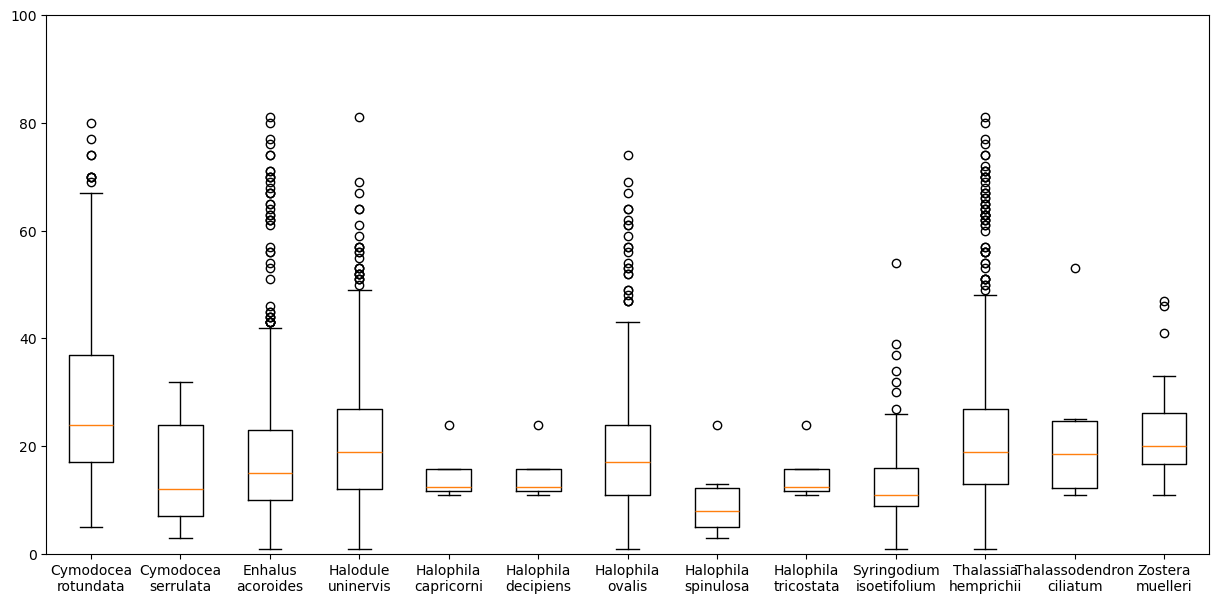

In [26]:
plt.figure(figsize=(15,7))
plt.boxplot(seagrass, tick_labels=seagrass.index)
plt.ylim(0,100)

In [27]:
# Drop empty arrays from the seagrass series

# Assuming `series` is your Pandas Series of arrays
# series = series[series.apply(lambda x: len(x) > 0)]

seagrass2 = seagrass[seagrass.apply(lambda x: len(x) > 0)]

Text(0.5, 1.0, 'Data density distribution (Violin) plot of exposure\n values per seagrass species with deciles (red)')

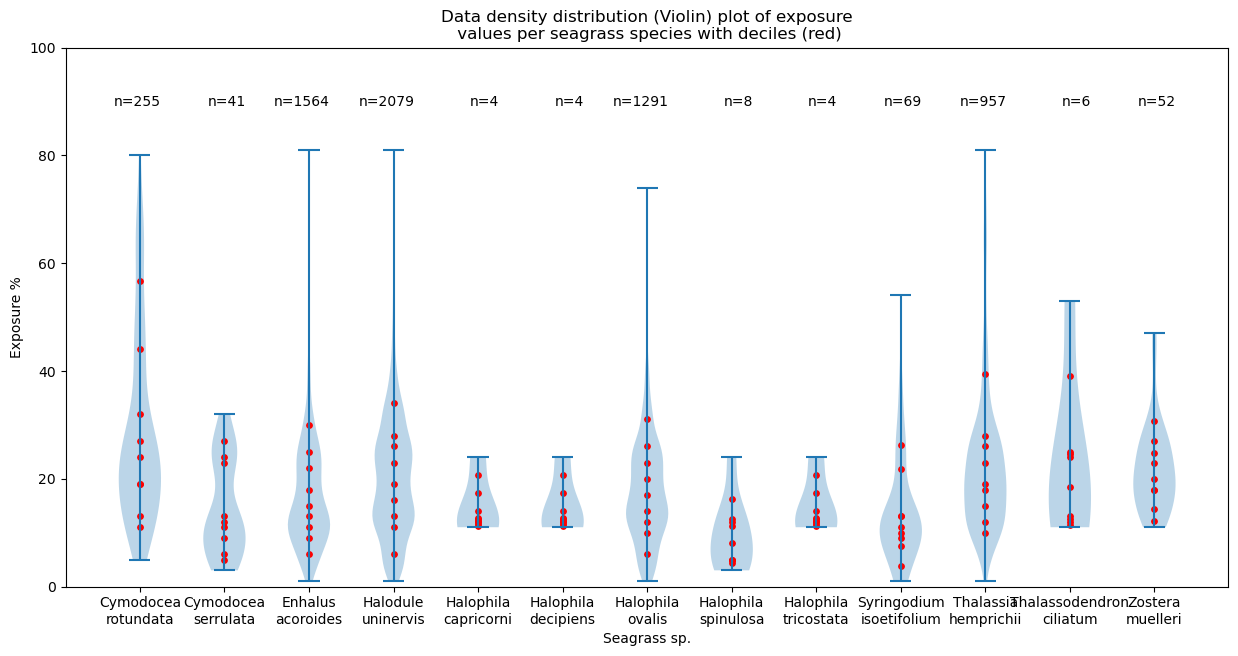

In [28]:
data = list(seagrass2)
deciles = [np.percentile(values, np.arange(10,100,10)) for values in data]
seagrass_counts = pd.Series(data = list(len(x) for x in seagrass2.array), index = seagrass2.index)

plt.figure(figsize=(15,7))
plt.violinplot(data)

for i, decile_values in enumerate(deciles, start=1):
    plt.scatter([i] * len(decile_values), decile_values, color='r', marker='o', s=15, label='Deciles' if i==1 else "")

for i, (name,count) in enumerate(seagrass_counts.items()):
    plt.text(i+1.25, 90, f'n={count}', ha='right', va = 'center', color='black',
             bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

plt.xticks(range(1,len(seagrass2) +1), seagrass2.index)
plt.ylim(0,100)

plt.xlabel("Seagrass sp.")
plt.ylabel("Exposure %")
plt.title("Data density distribution (Violin) plot of exposure\n values per seagrass species with deciles (red)")

In [29]:
data_TS_GoC = copy.deepcopy(seagrass)

In [30]:
%store data_TS_GoC

Stored 'data_TS_GoC' (Series)
